In [1]:
import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jr
import jax.scipy.special as jss
import healpy as hp
import astropy as ap
from astropy.coordinates import SkyCoord
from dustmaps.edenhofer2023 import Edenhofer2023Query
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

def general_matern_spectral_density(omega, inference_params, jitter = 1e-6):
        logvar, logscale, lognu = inference_params
        nu = jnp.exp(lognu)
        log_ratio = jss.gammaln(nu + 0.5) - jss.gammaln(nu)
        r = jnp.square(omega) * jnp.exp(2 * logscale - jnp.log(2.0) - lognu)
        logdensity = logvar + log_ratio - 0.5*jnp.log(2*nu) + logscale - (nu + 0.5)*jnp.log1p(r)
        result = 2*jnp.sqrt(jnp.pi)*jnp.exp(logdensity)
        return result


def matern_magnitude(omega, inference_params):
    return jnp.sqrt(general_matern_spectral_density(omega, inference_params))

def get_omegas(L, N):
     return 2*jnp.pi*jnp.fft.fftfreq(N, d = L/N)



def fft_field_hartley(noise, fourier_length, num_fourier_entries, num_entries, inference_params):
    size = noise.shape[0]
    omegas = get_omegas(fourier_length, num_fourier_entries)
    raw_average_amplitude_data = matern_magnitude(omegas, inference_params)
    normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)
    H = noise * raw_average_amplitude_data         
    y_data = (hartley(H) / size) * normalization_factor
    return y_data[0:num_entries]

def hartley(x):
    X = jnp.fft.fft(x)
    return jnp.real(X) - jnp.imag(X)

def fold_spectrum(X):
    N = X.shape[0]
    m = N // 2 + 1
    full_fold = ((X + jnp.roll(X[::-1], 1)) / 2)[:m]
    return full_fold[1:]

def get_spectrum(field, fourier_length, num_fourier_entries):
    normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)
    omegas = get_omegas(fourier_length, num_fourier_entries)
    spectra_with_noise = hartley(field)/normalization_factor
    log_spectrum = jnp.log(fold_spectrum(spectra_with_noise**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept


def get_spectrum2(field, fourier_length, num_fourier_entries):
    normalization_factor = num_fourier_entries/jnp.sqrt(fourier_length)
    omegas = get_omegas(fourier_length, num_fourier_entries)
    spectra_with_noise = jnp.fft.fft(field)/normalization_factor
    log_spectrum = jnp.log(fold_spectrum(jnp.abs(spectra_with_noise)**2))
    log_omegas = jnp.log(fold_spectrum(jnp.abs(omegas)))
    slope, intercept = jnp.polyfit(log_omegas, log_spectrum, 1)
    return log_omegas, log_spectrum, slope, intercept

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


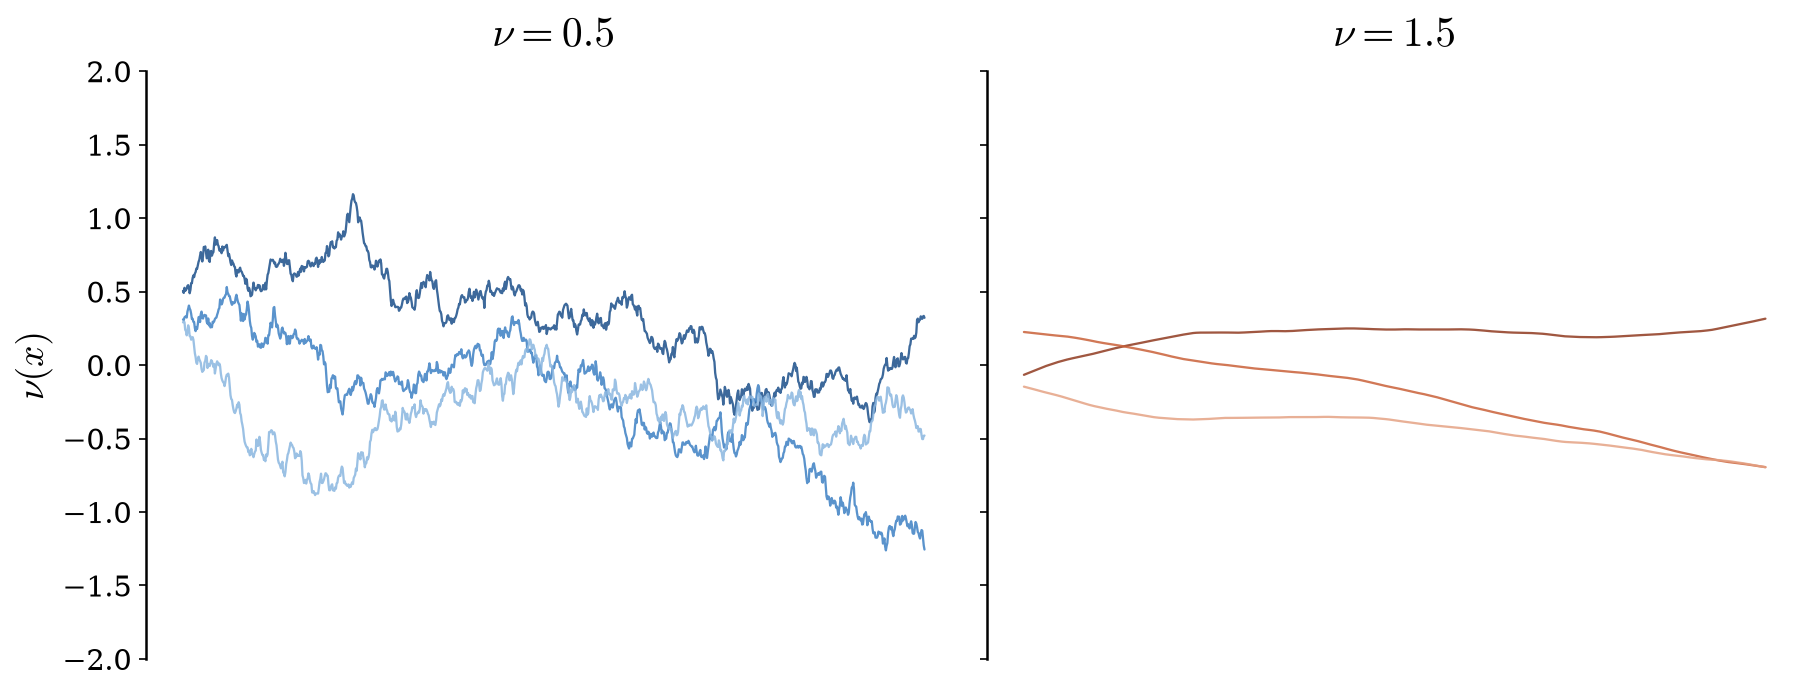

In [2]:
rng = jr.PRNGKey(56)
rng, k1, k2, k3 = jr.split(rng, 4)
xi_1 = jr.normal(k1, shape = (1, 10000))
xi_2 = jr.normal(k2, shape = (3, 10000))
xi_3 = jr.normal(k3, shape = (3, 10000))

xi = jr.normal(k1, shape = (10000, ))
linspace = jnp.arange(1000)*0.001

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "ytick.labelsize": 14,
    "axes.linewidth": 1.2,
    "figure.dpi": 150,
    "savefig.bbox": "tight",
})

rng = jr.PRNGKey(56)
rng, k1, k2, k3 = jr.split(rng, 4)
xi_1 = jr.normal(k1, shape=(3, 10000))
xi_2 = jr.normal(k2, shape=(3, 10000))
linspace = jnp.arange(1000) * 0.001

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True,
                         constrained_layout=True)

panels = [
    (xi_1, jnp.log(0.5), r"$\nu = 0.5$", ["#1b4f8a", "#3d80c4", "#8ab6e0"]),
    (xi_1, jnp.log(1.5), r"$\nu = 1.5$", ["#8f3a1f", "#c96038", "#e5a284"]),
]

for ax, (xi, alpha, title, shades) in zip(axes, panels):
    for i in range(3):
        nu = fft_field_hartley(xi[i], 10, 10000, 1000, (0, jnp.log(2), alpha))
        ax.plot(linspace, nu, lw=1.1, color=shades[i], alpha=0.85,
                solid_capstyle="round")
    ax.set_ylim(-2, 2)
    ax.set_xticks([])
    for s in ("bottom", "top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_title(title, pad=12)

axes[0].set_ylabel(r"$\nu(x)$")
plt.rcParams.update({
    "svg.fonttype": "path",   # glyphs → outlines, no font lookup needed
    "savefig.bbox": None,     # let constrained_layout own the padding
    "savefig.pad_inches": 0.1,
})

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
})

fig.savefig("spectra.svg")

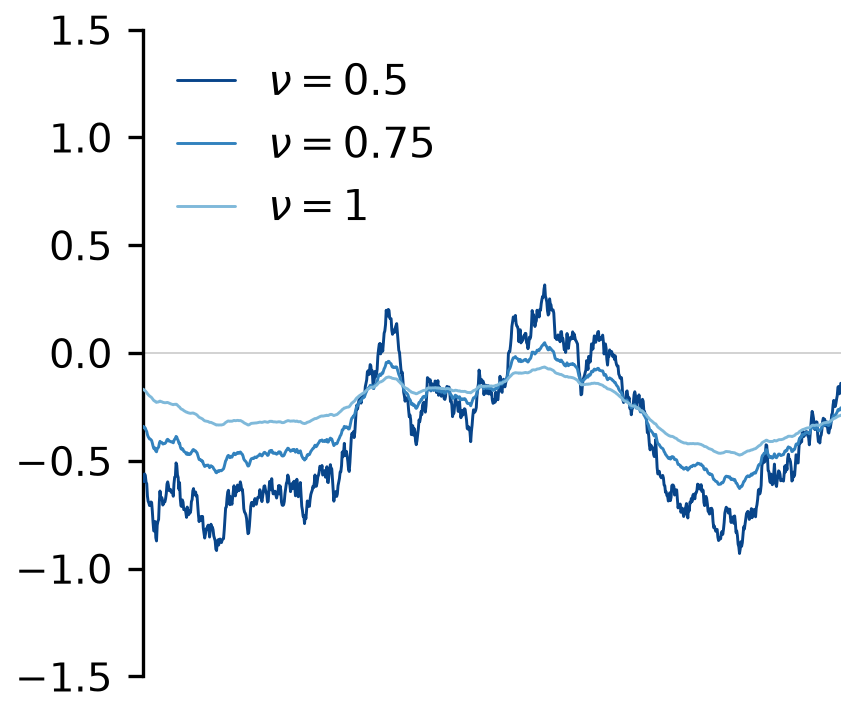

In [3]:
"""
Poster-ready panel figure for Hartley/FFT Gaussian random fields.
 
One fixed xi is shared by every field, so the three curves are the *same*
underlying realisation seen at three smoothness parameters nu -- the differences
between panels are the effect of nu alone, not seed noise.
 
Style: all three nus on one axes, shaded within a single hue family so the
curves read as one object seen at three smoothings. Left spine and y ticks only,
no x-axis furniture, so the eye goes straight to the curve shapes.
`plot_field_panels` keeps the same look split across side-by-side panels.
 
Requires your own field generator in scope:
    fft_field_hartley(xi, n_modes, n_xi, n_grid, (offset, log_amp, log_nu))
"""
 
from __future__ import annotations
 
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
 
# ----------------------------------------------------------------------
# Global look. pdf/ps fonttype 42 keeps text editable in Illustrator, and
# svg.fonttype "none" keeps it as real text in SVG -- both matter for posters.
# ----------------------------------------------------------------------
POSTER_RC = {
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.linewidth": 1.6,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
}
 
# One hue family per panel.
HUE_FAMILIES = ("Blues", "Oranges", "Greens", "Purples", "YlOrBr", "Greys")
 
N_XI = 10_000
N_GRID = 1_000
DX = 0.001
N_MODES = 10
 
 
def family_shade(cmap_name: str, t: float = 0.85):
    """A single strong colour from a sequential colormap."""
    return plt.get_cmap(cmap_name)(t)
 
 
def shade_ramp(cmap_name: str, n: int, dark: float = 0.92, light: float = 0.45):
    """n colours from one hue family, darkest first (used by the overlay)."""
    cmap = plt.get_cmap(cmap_name)
    return [cmap(t) for t in np.linspace(dark, light, n)]
 
 
def draw_fields(xi, nus, log_amp: float = jnp.log(2.0)):
    """
    One field per nu, all driven by the same fixed xi.
 
    Returns an array of shape (len(nus), N_GRID).
    """
    return jnp.stack(
        [
            fft_field_hartley(  # noqa: F821  (your generator)
                xi, N_MODES, N_XI, N_GRID, (0.0, log_amp, jnp.log(nu))
            )
            for nu in nus
        ]
    )
 
 
def _nice_symmetric_limit(fields, pad: float = 1.08, step: float = 0.5) -> float:
    """Symmetric y-limit rounded up to a clean multiple of `step`."""
    raw = float(jnp.max(jnp.abs(fields))) * pad
    return float(np.ceil(raw / step) * step)
 
 
def plot_field_panels(
    fields,
    nus,
    x=None,
    ylim=None,
    families=HUE_FAMILIES,
    panel_width: float = 4.6,
    panel_height: float = 5.4,
    linewidth: float = 1.4,
    title_size: int = 30,
    label_size: int = 26,
    tick_size: int = 19,
    zero_line: bool = True,
):
    """Render (n_nu, n_grid) fields as a row of clean panels, one curve each."""
    fields = np.atleast_2d(np.asarray(fields))
    n_panels, n_grid = fields.shape
    if x is None:
        x = np.arange(n_grid) * DX
    if ylim is None:
        ylim = _nice_symmetric_limit(fields)
 
    with plt.rc_context(POSTER_RC):
        fig, axes = plt.subplots(
            1,
            n_panels,
            figsize=(panel_width * n_panels, panel_height),
            sharey=True,
            gridspec_kw={"wspace": 0.07},
        )
        axes = np.atleast_1d(axes)
 
        for j, (ax, nu) in enumerate(zip(axes, nus)):
            if zero_line:
                ax.axhline(0.0, color="0.82", lw=0.9, zorder=0)
 
            ax.plot(
                x,
                fields[j],
                color=family_shade(families[j % len(families)]),
                lw=linewidth,
                solid_capstyle="round",
                solid_joinstyle="round",
                zorder=3,
            )
 
            ax.set_title(rf"$\nu = {float(nu):g}$", fontsize=title_size, pad=22)
            ax.set_xlim(x[0], x[-1])
            ax.set_ylim(-ylim, ylim)
            ax.set_xticks([])
 
            # Keep the left spine everywhere: on panel 0 it is the axis, on the
            # rest it is a divider. Everything else goes.
            for side in ("top", "right", "bottom"):
                ax.spines[side].set_visible(False)
            ax.spines["left"].set_color("black")
 
            if j == 0:
                ax.tick_params(
                    axis="y", labelsize=tick_size, length=7, width=1.6, pad=8
                )
                ax.set_ylabel(r"$\nu(x)$", fontsize=label_size, labelpad=16)
            else:
                ax.tick_params(axis="y", length=0)
 
        return fig, axes
 
 
def plot_field_overlay(
    fields,
    nus,
    x=None,
    ylim=None,
    family: str = "Blues",
    figsize=(6.0, 5.6),
    linewidth: float = 1.4,
    label_size: int = 26,
    tick_size: int = 19,
    legend_size: int = 20,
    zero_line: bool = True,
):
    """
    All nus on one axes, shaded within a single hue family.
 
    Because xi is fixed, the curves share a backbone, so the overlay shows nu
    smoothing that backbone directly. Darkest shade is the first nu.
    """
    fields = np.atleast_2d(np.asarray(fields))
    n_curves, n_grid = fields.shape
    if x is None:
        x = np.arange(n_grid) * DX
    if ylim is None:
        ylim = _nice_symmetric_limit(fields)
 
    with plt.rc_context(POSTER_RC):
        fig, ax = plt.subplots(figsize=figsize)
 
        if zero_line:
            ax.axhline(0.0, color="0.82", lw=0.9, zorder=0)
 
        for j, colour in enumerate(shade_ramp(family, n_curves)):
            ax.plot(
                x,
                fields[j],
                color=colour,
                lw=linewidth,
                solid_capstyle="round",
                label=rf"$\nu = {float(nus[j]):g}$",
                zorder=3 + j,
            )
 
        ax.set_xlim(x[0], x[-1])
        ax.set_ylim(-ylim, ylim)
        ax.set_xticks([])
        for side in ("top", "right", "bottom"):
            ax.spines[side].set_visible(False)
        ax.tick_params(axis="y", labelsize=tick_size, length=7, width=1.6, pad=8)
        ax.legend(
            fontsize=legend_size,
            frameon=False,
            loc="upper left",
            handlelength=1.4,
            borderaxespad=0.4,
        )
 
        return fig, ax
 
 
def save_poster_figure(fig, stem: str = "field_panels", dpi: int = 400):
    """Vector for print, raster for slides/preview."""
    for ext in ("pdf", "svg"):
        fig.savefig(f"{stem}.{ext}", bbox_inches="tight", pad_inches=0.05)
    fig.savefig(f"{stem}.png", dpi=dpi, bbox_inches="tight", pad_inches=0.05)
 
 
if __name__ == "__main__":
    xi = jr.normal(jr.PRNGKey(12), shape=(N_XI,))  # fixed for every nu
    nus = jnp.array([0.5, 0.75, 1.0])
    fields = draw_fields(xi, nus)
 
    fig, ax = plot_field_overlay(fields, nus)
    save_poster_figure(fig, "field_overlay")
    plt.show()
 

In [4]:
with fits.open("../Data_And_Samplers/samples_healpix.fits") as hdul:
    hdul.info()
    pix = hp.pixelfunc.ang2pix(256, theta=0.0, phi=0.0, nest=True, lonlat=True)
    samples_gc = hdul["SAMPLES"].data[:, :, pix]          
    radii = hdul["radial pixel centers"].data["radial pixel centers"]  

with fits.open("../Data_And_Samplers/mean_and_std_healpix.fits") as hdul:
    hdul.info()
    galactic_center_healpix = hp.pixelfunc.ang2pix(256, theta = 0.0, phi = 0.0, nest = True, lonlat = True)
    mean_dust_data_along_galactic_center = hdul["MEAN"].data[:, galactic_center_healpix]
    std_dust_data_along_galactic_center = hdul["STD."].data[:, galactic_center_healpix]
    healpix_size = hdul["MEAN"].data[0, :].size
    data_x = hdul['RADIAL PIXEL CENTERS'].data.field(0)
    distance_boundaries = hdul['RADIAL PIXEL BOUNDARIES'].data.field(0)
    distance_gaps = np.diff(distance_boundaries)
    integrated_dust = np.dot(distance_gaps, hdul["MEAN"].data)


samples_gc = jnp.asarray(np.ascontiguousarray(samples_gc).astype(np.float32))
mean_dust_data_along_galactic_center = jnp.asarray(np.ascontiguousarray(mean_dust_data_along_galactic_center).astype(np.float32))
log_samples = jnp.log(samples_gc)
radii = jnp.asarray(np.ascontiguousarray(radii).astype(np.float32))



Filename: ../Data_And_Samplers/samples_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  SAMPLES       1 ImageHDU        21   (786432, 516, 12)   float32   
  2  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  3  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  4  INTEGRATED INNER 68.8 PC    1 ImageHDU        18   (786432, 12)   float32   


Filename: ../Data_And_Samplers/mean_and_std_healpix.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       9   ()      
  1  MEAN          1 ImageHDU        19   (786432, 516)   float32   
  2  STD.          1 ImageHDU        19   (786432, 516)   float32   
  3  RADIAL PIXEL CENTERS    1 BinTableHDU     20   516R x 1C   [E]   
  4  RADIAL PIXEL BOUNDARIES    1 BinTableHDU     20   517R x 1C   [E]   
  5  MEAN OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   
  6  STD. OF INTEGRATED INNER 68.8 PC    1 ImageHDU        16   (786432,)   float32   


In [5]:
overall_data_arr = jnp.asarray(np.load("../sherlock_results_2/overall_data_Gaia_XP_fitting_actual_data_40345618_combined.npy"))
left_distance_padding = 40
right_distance_padding = 600
num_dimensions = 600
num_fourier_dimensions = 6000
min_distance = distance_boundaries[0] - left_distance_padding
max_distance = distance_boundaries[distance_boundaries.size - 1] + right_distance_padding
dx = (max_distance - min_distance)/(num_dimensions - 1)
fourier_length = dx*(num_fourier_dimensions - 1)
fixed_logscale = jnp.log(2*(max_distance - min_distance))

logvars = overall_data_arr[:, 0]
lognus = overall_data_arr[:, 1]
logscales = jnp.ones_like(lognus)*fixed_logscale
offsets = overall_data_arr[:, 2]
inference_params = (logvars, logscales, lognus)
overall_extinction_arr = overall_data_arr[:, 3:3 + num_fourier_dimensions]

overall_extinction_arr_raw_before_offsets = jax.vmap(fft_field_hartley, in_axes=(0, None, None, None, 0))(
    overall_extinction_arr, fourier_length, num_fourier_dimensions, num_dimensions, inference_params
)
overall_extinction_arr_raw = overall_extinction_arr_raw_before_offsets + offsets[:, None]


num_lower_indices_to_cut = int(round(left_distance_padding / dx))
num_upper_indices_to_cut = int(round(right_distance_padding / dx))

n = overall_extinction_arr_raw.shape[1]
overall_extinction_arr_trimmed = overall_extinction_arr_raw[
    :, num_lower_indices_to_cut : n - num_upper_indices_to_cut
]




(<Figure size 1425x900 with 1 Axes>,
 <Axes: xlabel='$\\nu$', ylabel='Probability Density'>)

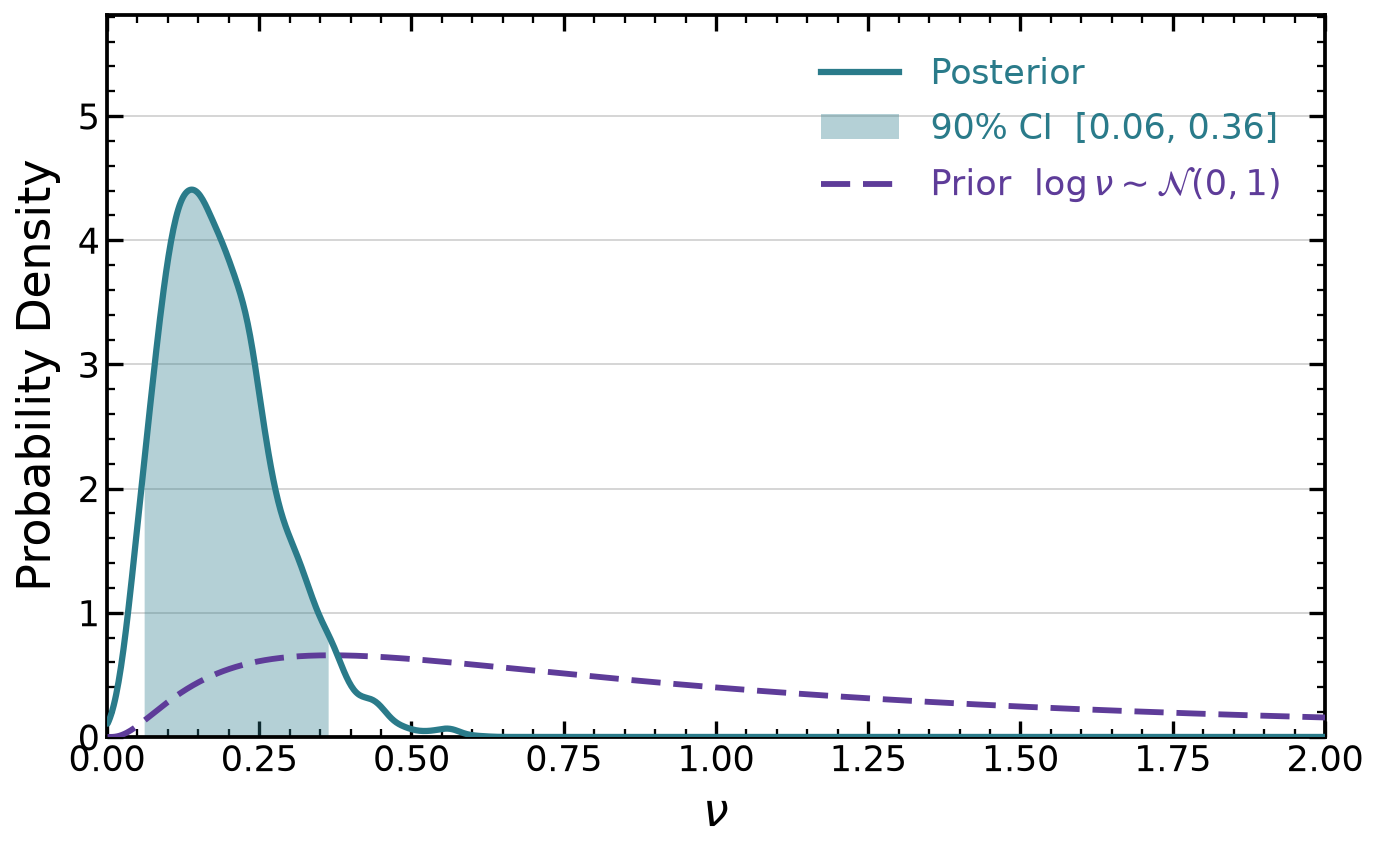

In [6]:
import jax.numpy as jnp
from jax.scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
 
# ---------------------------------------------------------------- palette
POSTERIOR = "#2A7B8A"   # teal, as in the HMC row
PRIOR     = "#5E3C99"   # purple
INK       = "#000000"
GRID      = "#D4D4D4"
MUTED     = "#7A7A7A"
 
 
def _set_style(base=17):
    """Heavy black box, inward ticks on all four sides, faint horizontal grid."""
    mpl.rcParams.update({
        "font.family":        "sans-serif",
        "font.sans-serif":    ["DejaVu Sans"],
        "mathtext.fontset":   "dejavusans",
        "font.size":          base,
        "axes.labelsize":     base + 5,
        "xtick.labelsize":    base,
        "ytick.labelsize":    base,
        "legend.fontsize":    base,
        # --- box
        "axes.edgecolor":     INK,
        "axes.linewidth":     1.8,
        "axes.spines.top":    True,
        "axes.spines.right":  True,
        # --- ticks
        "xtick.direction":    "in",
        "ytick.direction":    "in",
        "xtick.top":          True,
        "ytick.right":        True,
        "xtick.major.size":   7.5,
        "ytick.major.size":   7.5,
        "xtick.minor.size":   4,
        "ytick.minor.size":   4,
        "xtick.major.width":  1.6,
        "ytick.major.width":  1.6,
        "xtick.minor.width":  1.1,
        "ytick.minor.width":  1.1,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.color":        INK,
        "ytick.color":        INK,
        # --- grid sits behind the curves
        "axes.grid":          False,
        "grid.color":         GRID,
        "grid.linewidth":     0.9,
        "axes.axisbelow":     True,
        # --- output
        "figure.facecolor":   "white",
        "axes.facecolor":     "white",
        "savefig.facecolor":  "white",
        "pdf.fonttype":       42,
        "ps.fonttype":        42,
    })
 
 
def log_normal_pdf(nu, mu=0.0, sigma=1.0):
    """Log-normal density: log(nu) ~ Normal(mu, sigma^2)."""
    log_nu = jnp.log(nu)
    return jnp.exp(-0.5 * ((log_nu - mu) / sigma) ** 2) / (
        nu * sigma * jnp.sqrt(2 * jnp.pi)
    )
 
 
def plot_nu(lognus, xmax=2.0, ci=0.90, save=None, truth=None):
    """
    Parameters
    ----------
    lognus : posterior draws of log(nu)
    xmax   : right edge of the plotted range
    ci     : central credible mass to shade
    save   : basename; writes <save>.pdf and <save>.png at 400 dpi
    truth  : optional known value of nu, drawn as a vertical rule
    """
    _set_style()
 
    nus = jnp.exp(jnp.asarray(lognus).ravel())
    kde = gaussian_kde(nus)
 
    # start strictly above 0: log(0) = -inf would put a nan in the prior curve
    grid = jnp.linspace(1e-3, xmax, 1000)
    post = kde(grid)
    pri = log_normal_pdf(grid)
 
    lo, hi = (float(v) for v in jnp.percentile(
        nus, jnp.array([50 * (1 - ci), 50 * (1 + ci)])))
 
    fig, ax = plt.subplots(figsize=(9.5, 6.0))
    ax.grid(axis="y", zorder=0)
 
    # --- single central credible interval under the posterior curve
    ax.fill_between(grid, post, where=(grid >= lo) & (grid <= hi),
                    color=POSTERIOR, alpha=0.35, lw=0, zorder=2)
    ax.plot(grid, post, color=POSTERIOR, lw=3.0, zorder=5, solid_capstyle="round")
 
    # --- prior: dashed outline only, so it recedes behind the posterior
    ax.plot(grid, pri, color=PRIOR, lw=2.8, ls=(0, (5, 2.2)), zorder=4)
 
    if truth is not None:
        ax.axvline(truth, color=MUTED, lw=1.6, ls=":", zorder=1)
 
    ax.set_xlim(0, xmax)
    ax.set_ylim(0, float(max(post.max(), pri.max())) * 1.32)
    ax.set_xlabel(r"$\nu$", labelpad=6)
    ax.set_ylabel("Probability Density", labelpad=8)
 
    # --- CI numbers live in the legend, colour-matched to their series
    handles = [
        Line2D([], [], color=POSTERIOR, lw=3.0),
        Patch(facecolor=POSTERIOR, alpha=0.35, lw=0),
        Line2D([], [], color=PRIOR, lw=2.8, ls=(0, (5, 2.2))),
    ]
    labels = [
        "Posterior",
        f"{ci:.0%} CI  [{lo:.2f}, {hi:.2f}]",
        r"Prior  $\log\nu \sim \mathcal{N}(0,1)$",
    ]
    leg = ax.legend(handles, labels, frameon=False, loc="upper right",
                    handlelength=2.2, handletextpad=0.9, labelspacing=0.55,
                    borderaxespad=0.8)
    for text, colour in zip(leg.get_texts(), [POSTERIOR, POSTERIOR, PRIOR]):
        text.set_color(colour)
 
    fig.tight_layout()
 
    if save:
        fig.savefig(f"{save}.pdf", bbox_inches="tight")
        fig.savefig(f"{save}.png", dpi=400, bbox_inches="tight")
    return fig, ax
 
 
plot_nu(lognus, save="nu_poster")
 

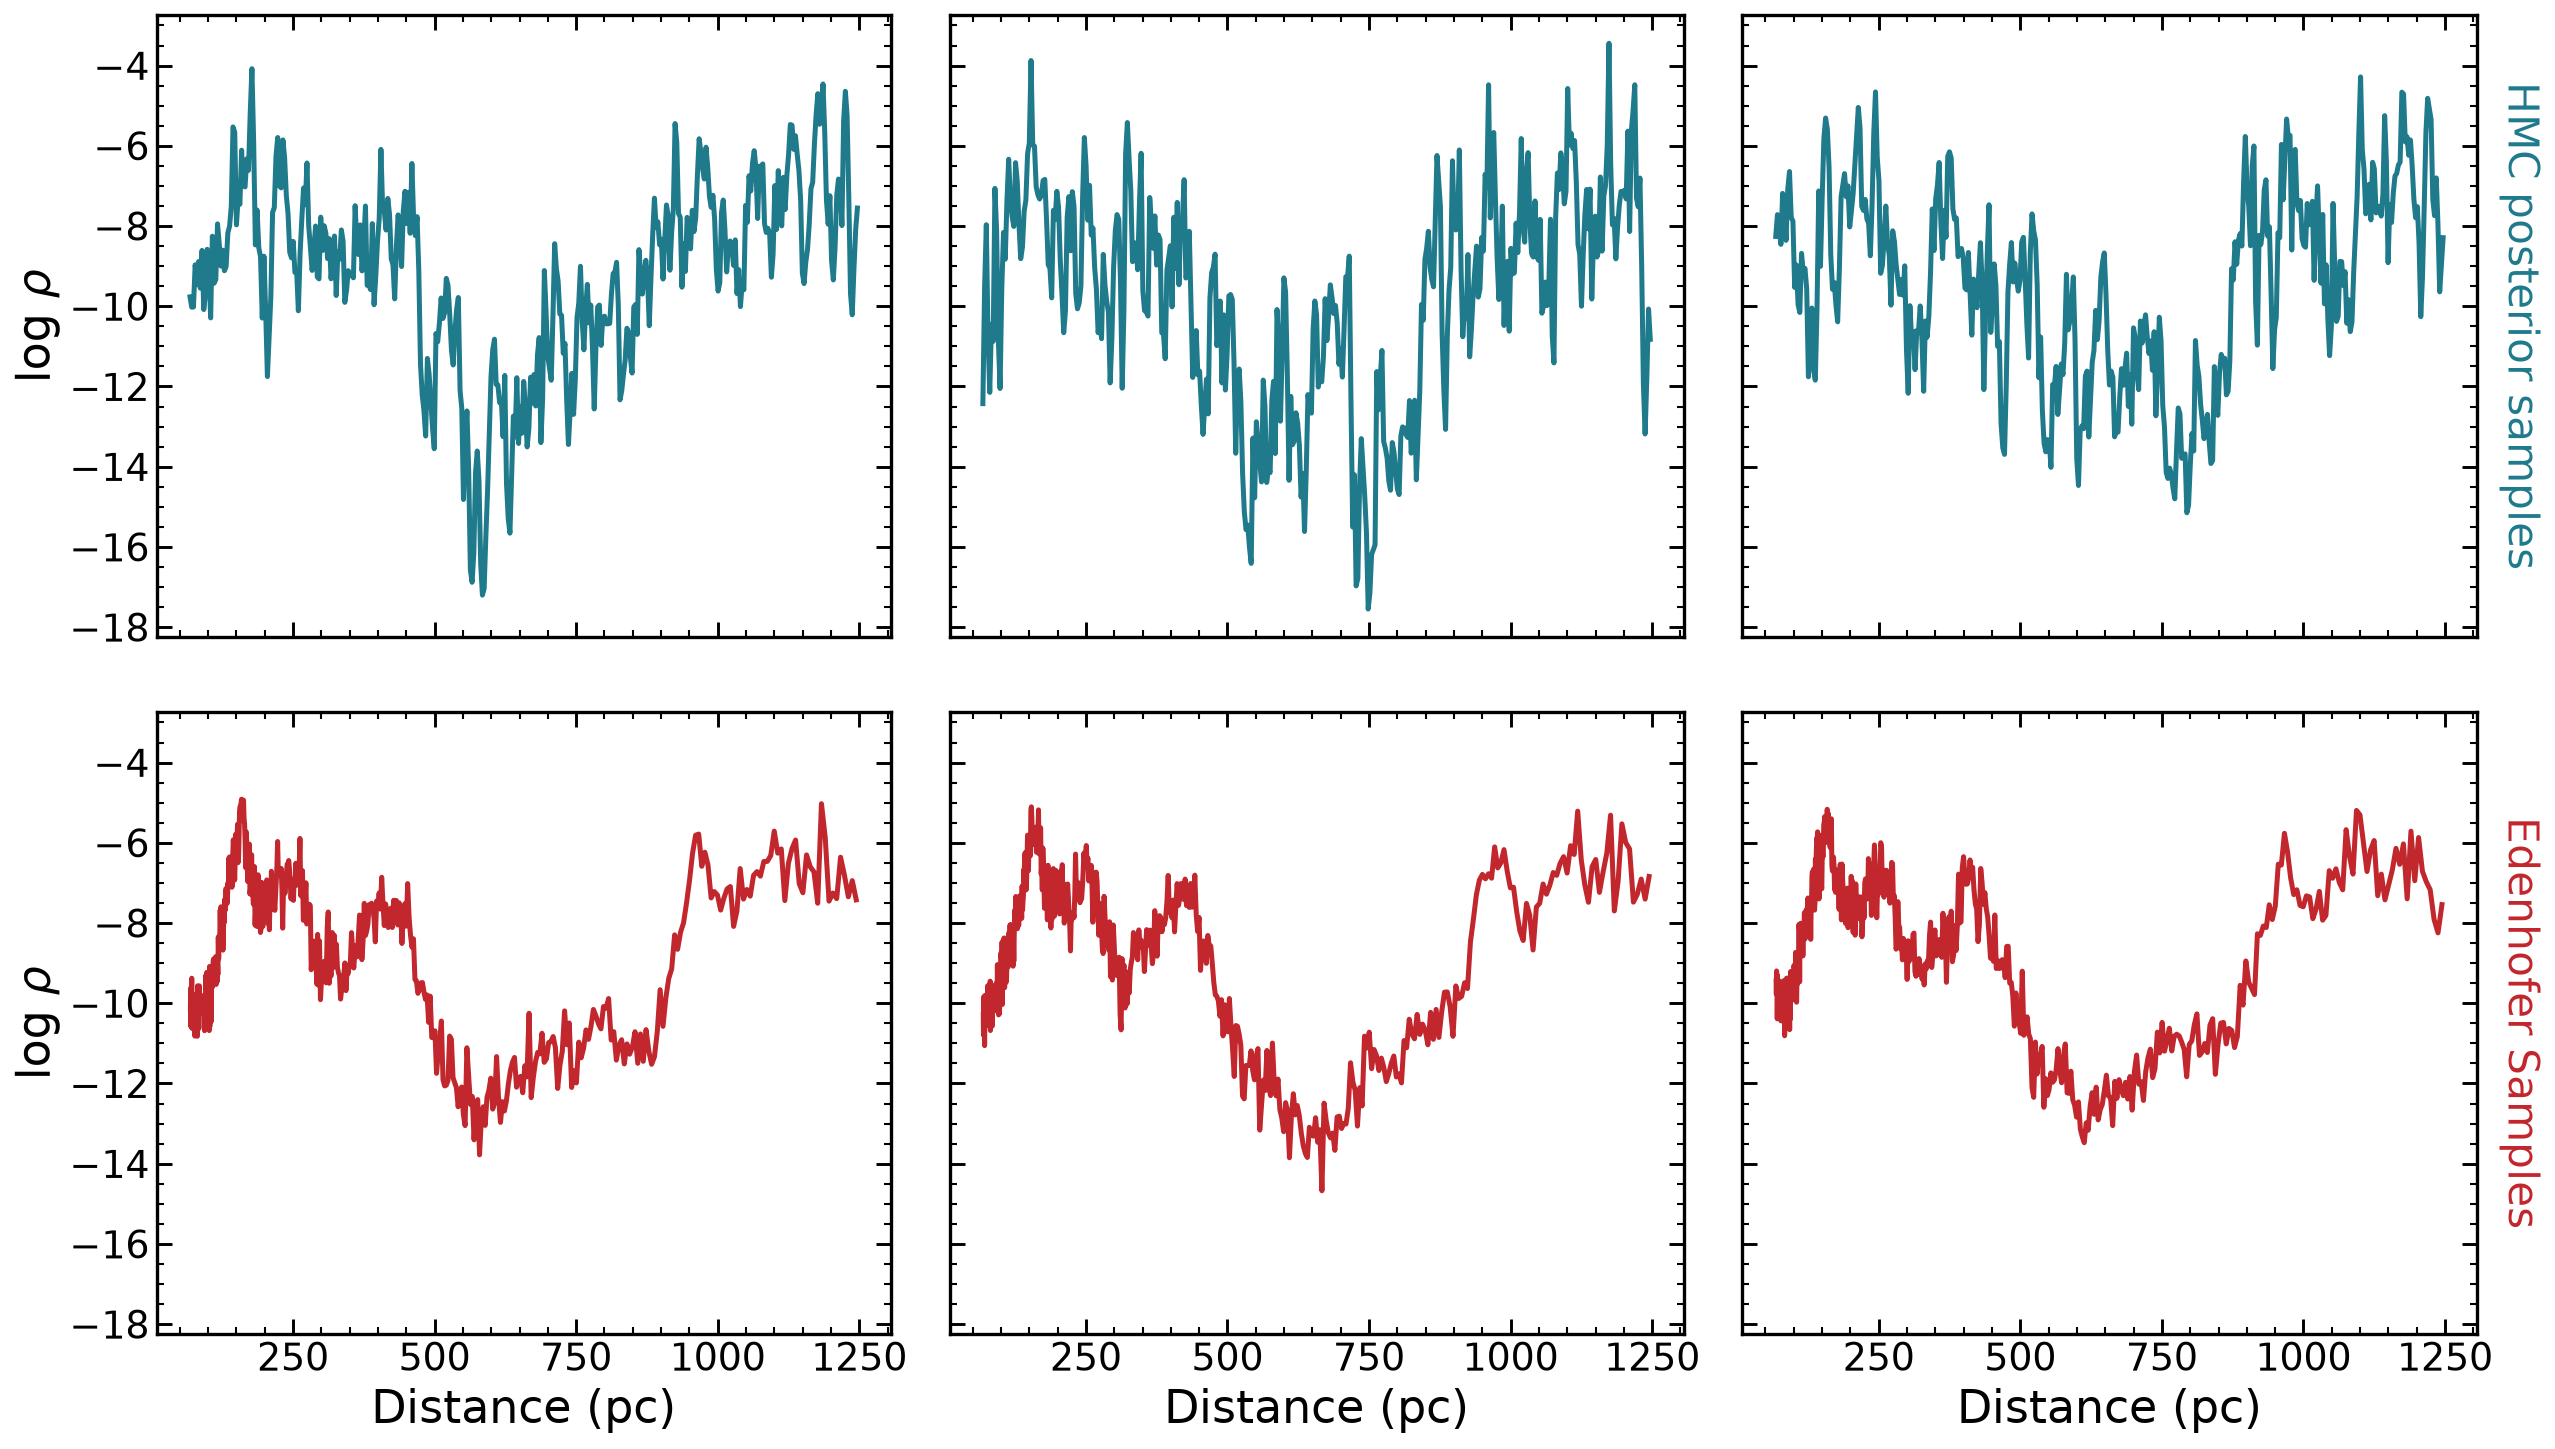

In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import jax.numpy as jnp

# ---------- poster styling ----------
mpl.rcParams.update({
    "figure.figsize": (18, 10), "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 18, "axes.labelsize": 22, "axes.titlesize": 22,
    "xtick.labelsize": 18, "ytick.labelsize": 18,
    "axes.linewidth": 1.6, "lines.linewidth": 2.4,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 7, "ytick.major.size": 7,
    "xtick.minor.size": 3.5, "ytick.minor.size": 3.5,
    "xtick.major.width": 1.4, "ytick.major.width": 1.4,
    "xtick.minor.width": 1.0, "ytick.minor.width": 1.0,
})

C_HMC  = "#1f7a8c"   # HMC posterior draws
C_TRUE = "#c1272d"   # prior / true-field draws

plotting_samples_linspace = (jnp.arange(n - num_lower_indices_to_cut - num_upper_indices_to_cut)*dx
                             + (min_distance + dx*num_lower_indices_to_cut))

fig, axes = plt.subplots(2, 3, sharex=True, sharey=True)

for i in range(3):
    axes[0][i].plot(plotting_samples_linspace, overall_extinction_arr_trimmed[10 + 10*i, :],
                    color=C_HMC, lw=2.4)
    axes[1][i].plot(data_x, log_samples[i, :], color=C_TRUE, lw=2.4)

    axes[1][i].set_xlabel("Distance (pc)")

# one y-label per row instead of six identical ones
axes[0][0].set_ylabel(r"$\log\,\rho$")
axes[1][0].set_ylabel(r"$\log\,\rho$")

# row annotations on the right edge
for row, text in zip((0, 1), ("HMC posterior samples", "Edenhofer Samples")):
    axes[row][2].annotate(text, xy=(1.03, 0.5), xycoords="axes fraction",
                          rotation=270, va="center", ha="left", fontsize=20,
                          color=C_HMC if row == 0 else C_TRUE)

fig.tight_layout()
fig.subplots_adjust(hspace=0.12, wspace=0.08, right=0.94)
fig.savefig("sample_draws_grid.pdf")
fig.savefig("sample_draws_grid.png")
plt.show()



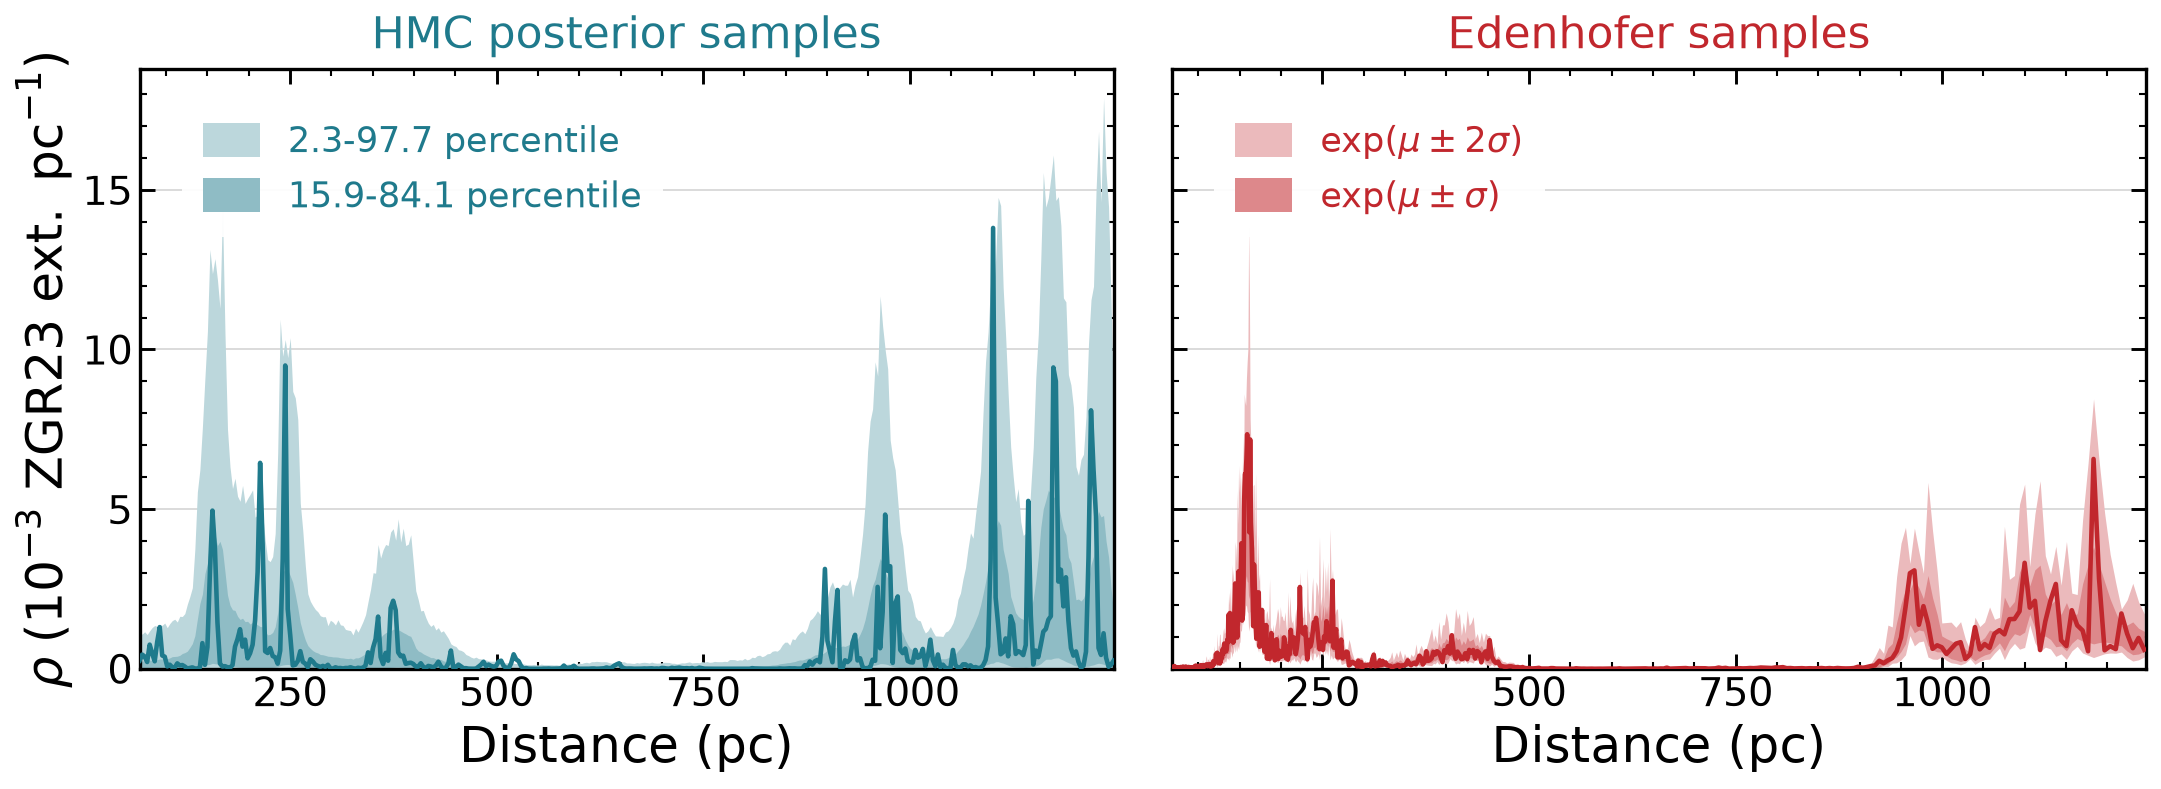

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator
import numpy as np
import jax.numpy as jnp
from scipy.stats import norm

z = np.array([-2, -1, 1, 2])
important_percentiles = norm.cdf(z) * 100
sigma_boundaries_array = np.percentile(overall_extinction_arr_trimmed,
                                       important_percentiles, axis=0)   # (4, n_cols)

log_samples = jnp.log(samples_gc)
log_samples_mean = jnp.mean(log_samples, axis = 0)
log_samples_std = jnp.std(log_samples, axis = 0)
log_samples_2_sigma_low_end, log_samples_1_sigma_low_end, log_samples_1_sigma_high_end, log_samples_2_sigma_high_end = log_samples_mean - 2*log_samples_std, log_samples_mean - log_samples_std, log_samples_mean + log_samples_std, log_samples_mean + 2*log_samples_std
# ---------- poster styling ----------
mpl.rcParams.update({
    "figure.figsize": (15, 5.6), "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 18, "axes.labelsize": 24, "axes.titlesize": 22,
    "xtick.labelsize": 19, "ytick.labelsize": 19,
    "axes.linewidth": 1.6, "lines.linewidth": 2.4,
    "xtick.direction": "in", "ytick.direction": "in",
    "xtick.top": True, "ytick.right": True,
    "xtick.minor.visible": True, "ytick.minor.visible": True,
    "xtick.major.size": 7, "ytick.major.size": 7,
    "xtick.minor.size": 3.5, "ytick.minor.size": 3.5,
    "xtick.major.width": 1.4, "ytick.major.width": 1.4,
    "xtick.minor.width": 1.0, "ytick.minor.width": 1.0,
    "axes.axisbelow": True, "legend.fontsize": 17,
})

C_HMC  = "#1f7a8c"   # HMC posterior draws
C_TRUE = "#c1272d"   # Edenhofer draws

C_1SIG_HMC = "#8fbcc5"   # C_HMC, 50% toward white
C_2SIG_HMC = "#bcd7dc"   # C_HMC, 70% toward white
C_1SIG     = "#dd888b"   # C_TRUE, 45% toward white
C_2SIG     = "#ebbabc"   # C_TRUE, 68% toward white

plotting_samples_linspace = (jnp.arange(n - num_lower_indices_to_cut - num_upper_indices_to_cut)*dx
                             + (min_distance + dx*num_lower_indices_to_cut))

# Intervals stay computed in log space; exp() only for display. Monotone, so
# exp(percentile) and exp(mu +/- k*sigma) are both valid bounds on rho.
hmc_x = np.asarray(plotting_samples_linspace)
sig_lo2, sig_lo1, sig_hi1, sig_hi2 = (np.exp(np.asarray(r)) for r in sigma_boundaries_array)

ed_x   = np.asarray(data_x)
ed_lo2 = np.exp(np.asarray(log_samples_2_sigma_low_end))
ed_hi2 = np.exp(np.asarray(log_samples_2_sigma_high_end))
ed_lo1 = np.exp(np.asarray(log_samples_1_sigma_low_end))
ed_hi1 = np.exp(np.asarray(log_samples_1_sigma_high_end))

# Labels built from the percentiles actually used, so they can never drift.
p_lo2, p_lo1, p_hi1, p_hi2 = important_percentiles
LBL_HMC_2 = f"{p_lo2:.1f}-{p_hi2:.1f} percentile"
LBL_HMC_1 = f"{p_lo1:.1f}-{p_hi1:.1f} percentile"
LBL_ED_2  = r"$\exp(\mu \pm 2\sigma)$"
LBL_ED_1  = r"$\exp(\mu \pm \sigma)$"

# which single draw to show in each panel
HMC_DRAW = 30
ED_DRAW  = 0

fig, axes = plt.subplots(1, 2, sharex=True, sharey=True)

# ---- left panel: HMC ----
ax = axes[0]
ax.fill_between(hmc_x, sig_lo2, sig_hi2, color=C_2SIG_HMC, lw=0, zorder=1,
                label=LBL_HMC_2)
ax.fill_between(hmc_x, sig_lo1, sig_hi1, color=C_1SIG_HMC, lw=0, zorder=2,
                label=LBL_HMC_1)
ax.plot(hmc_x, np.exp(np.asarray(overall_extinction_arr_trimmed[HMC_DRAW, :])),
        color=C_HMC, lw=2.2, zorder=3, solid_joinstyle="round")
ax.set_xlabel("Distance (pc)")

# ---- right panel: Edenhofer ----
ax = axes[1]
ax.fill_between(ed_x, ed_lo2, ed_hi2, color=C_2SIG, lw=0, zorder=1,
                label=LBL_ED_2)
ax.fill_between(ed_x, ed_lo1, ed_hi1, color=C_1SIG, lw=0, zorder=2,
                label=LBL_ED_1)
ax.plot(ed_x, np.exp(np.asarray(log_samples[ED_DRAW, :])),
        color=C_TRUE, lw=2.2, zorder=3, solid_joinstyle="round")
ax.set_xlabel("Distance (pc)")

# identical legend placement in both panels
for col_i, col in ((0, C_HMC), (1, C_TRUE)):
    leg = axes[col_i].legend(loc="upper left", bbox_to_anchor=(0.025, 0.975),
                             frameon=True, framealpha=0.92, edgecolor="none",
                             borderpad=0.6, labelspacing=0.5, handlelength=1.6,
                             handleheight=1.1)
    for t in leg.get_texts():
        t.set_color(col)
    leg.set_zorder(6)

# y in units of 1e-3 so the ticks lose their leading zeros
for ax in axes.ravel():
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*1e3:g}"))
    ax.grid(axis="y", color="0.85", lw=0.9, zorder=0)
axes[0].xaxis.set_major_locator(MultipleLocator(250))
axes[0].set_xlim(min(hmc_x.min(), ed_x.min()), max(hmc_x.max(), ed_x.max()))
axes[0].set_ylim(0, None)

lbl = r"$\rho\;(10^{-3}\ \mathrm{ZGR23\ ext.\ pc^{-1}})$"
axes[0].set_ylabel(lbl)

for col_i, text in zip((0, 1), ("HMC posterior sample", "Edenhofer sample")):
    axes[col_i].set_title(text, fontsize=21,
                          color=C_HMC if col_i == 0 else C_TRUE, pad=10)

fig.tight_layout()
fig.subplots_adjust(wspace=0.06)
fig.savefig("sample_draws_grid.pdf")
fig.savefig("sample_draws_grid.png")
plt.show()

Slope of best-fit line on Edenhofer sample is -1.7245512804429366 so nu is 0.3622756402214683
Slope of best-fit line on Edenhofer mean is is -1.9527181207560924 so nu is 0.4763590603780462
Slope of best-fit line with Hanning filter on Edenhofer sample is -1.8548852244170475 so nu is 0.42744261220852375
Slope of best-fit line with Hanning filter on Edenhofer mean is is -2.3741260556705956 so nu is 0.6870630278352978
Slope of best-fit line on control field with nu = 0.2 is is -1.3864275558883 so nu is 0.19321377794414996


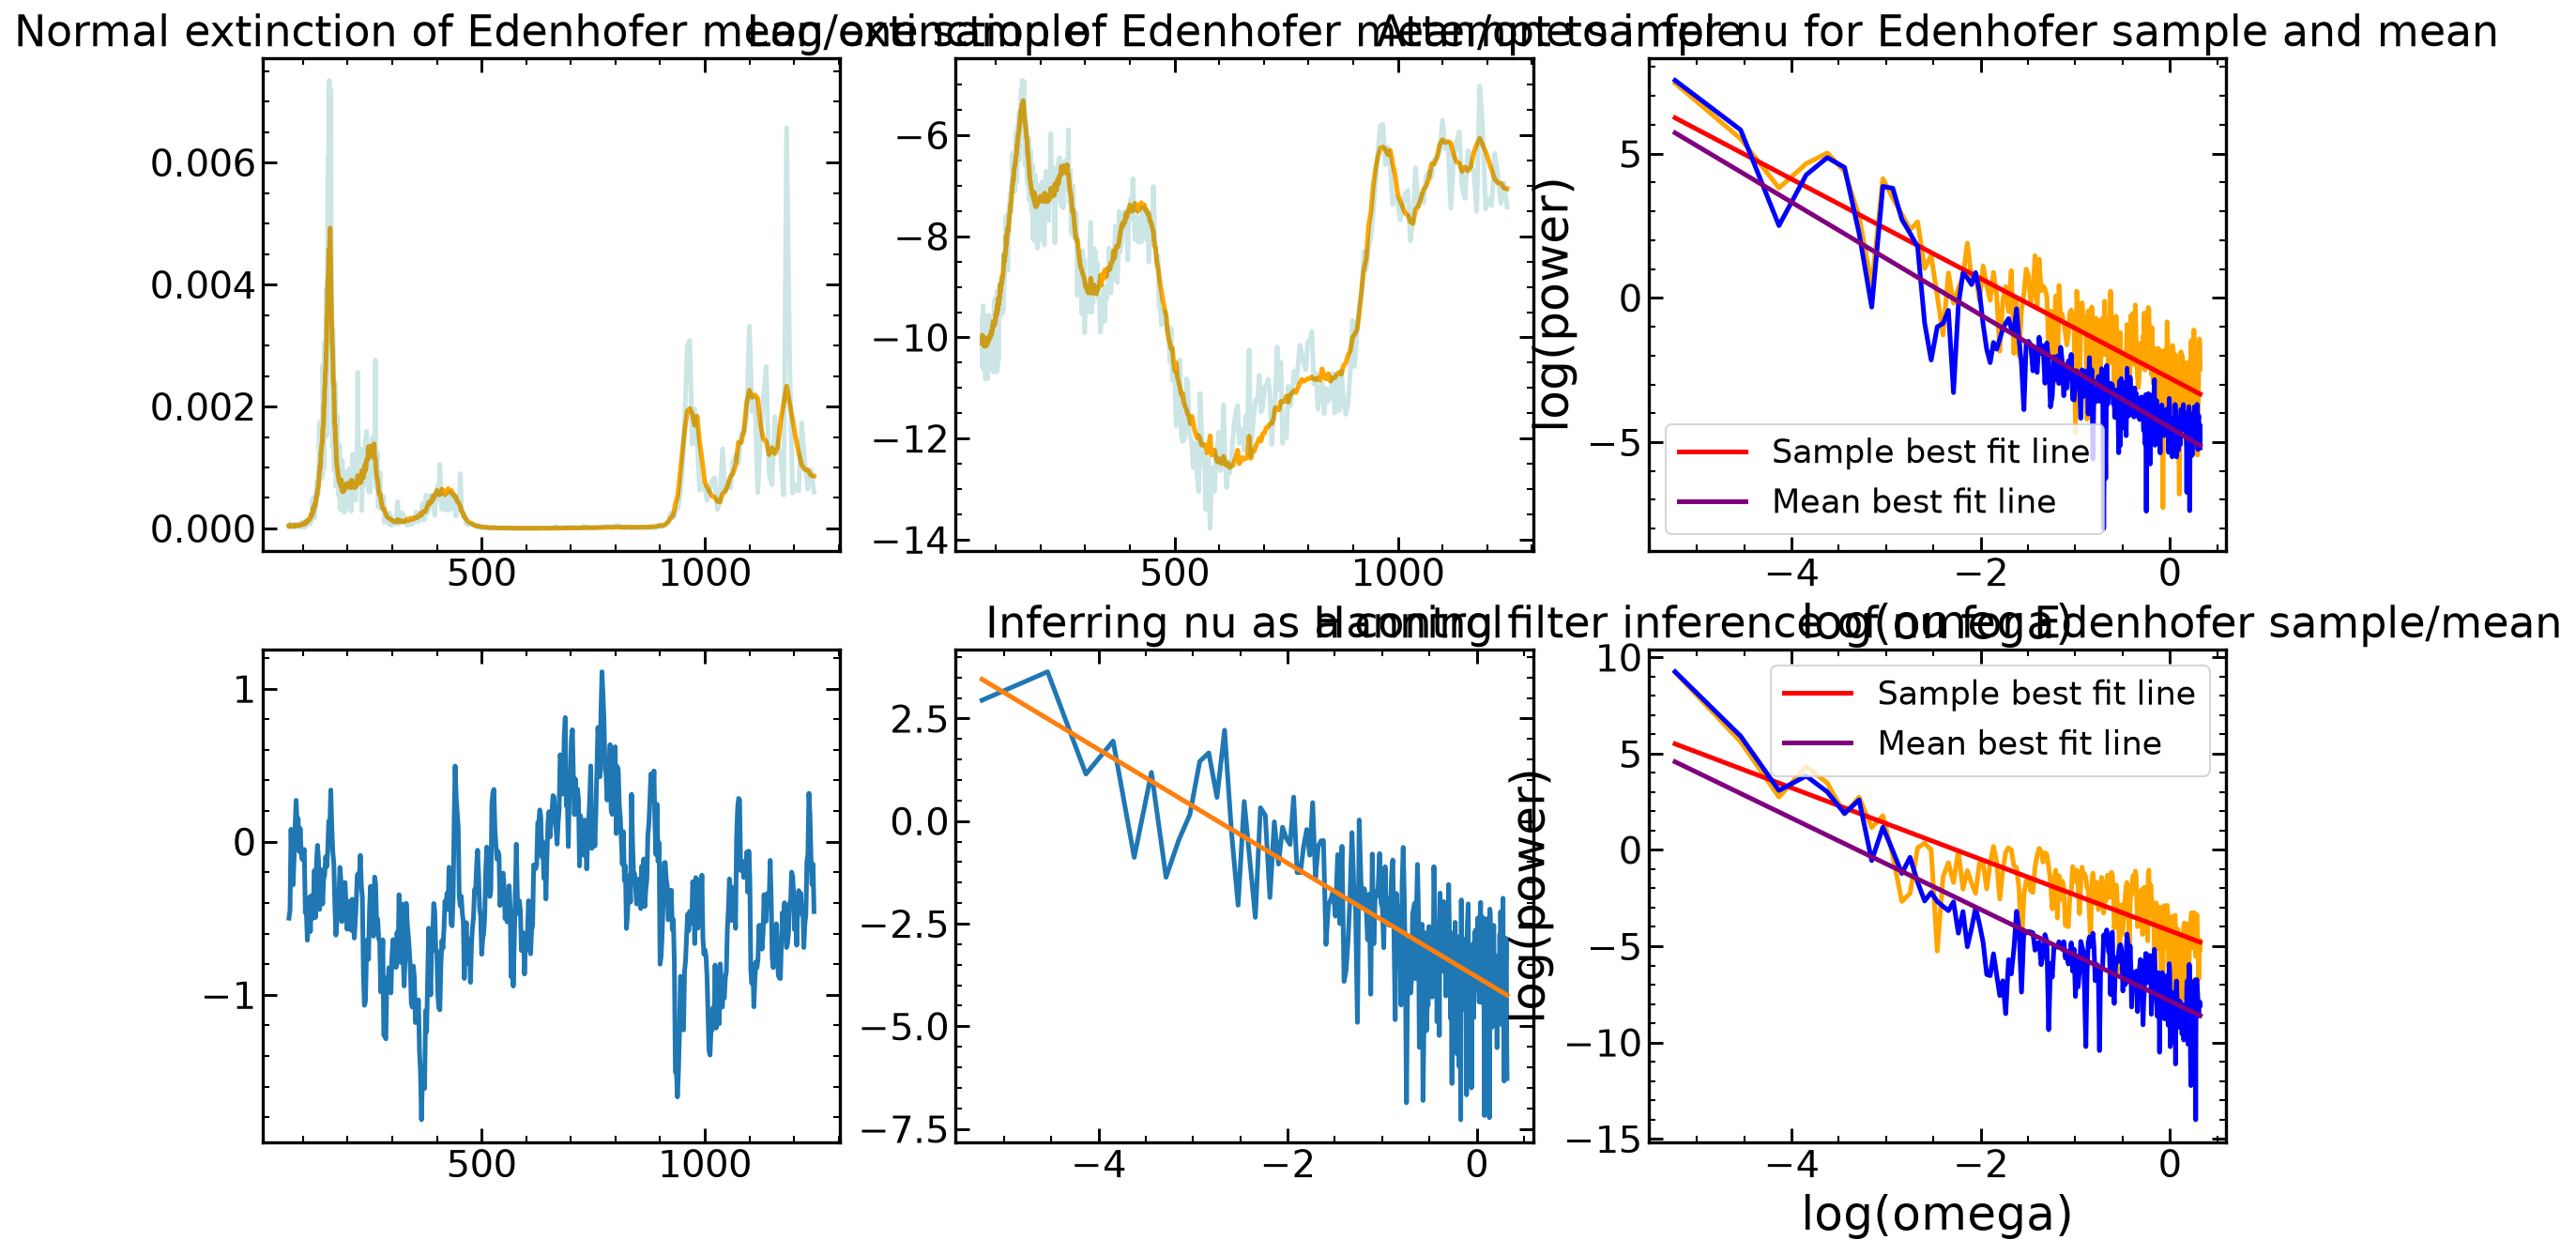

In [9]:
fig, axes = plt.subplots(2, 3, figsize = (18, 10))
axes[0][0].plot(radii, mean_dust_data_along_galactic_center, color = "orange")
axes[0][1].plot(radii, np.log(mean_dust_data_along_galactic_center), color = "orange")
for i in range (0, 1):
    axes[0][0].plot(radii, samples_gc[i, :], color = "teal", alpha = 0.2)
    axes[0][1].plot(radii, log_samples[i, :], color = "teal", alpha = 0.2)

axes[0][0].set_title("Normal extinction of Edenhofer mean/one sample")
axes[0][1].set_title("Log extinction of Edenhofer mean/one sample")
num_dims = radii.size
linspace = jnp.linspace(jnp.min(radii), jnp.max(radii), num_dims)
interp_sample = jnp.interp(linspace, radii, log_samples[0, :])
log_omegas, log_spectrum, slope_sample, intercept = get_spectrum2(interp_sample, jnp.max(radii) - jnp.min(radii), num_dims)
axes[0][2].plot(log_omegas, log_spectrum, color = "orange")
axes[0][2].plot(log_omegas, intercept + slope_sample*log_omegas, color = "red", label = "Sample best fit line")
axes[0][2].set_xlabel("log(omega)")
axes[0][2].set_ylabel("log(power)")

log_omegas, log_spectrum, slope_sample_hanning, intercept = get_spectrum2(interp_sample*jnp.hanning(num_dims), jnp.max(radii) - jnp.min(radii), num_dims)
axes[1][2].plot(log_omegas, log_spectrum, color = "orange")
axes[1][2].plot(log_omegas, intercept + slope_sample_hanning*log_omegas, color = "red", label = "Sample best fit line")
axes[1][2].set_title("Hanning filter inference of nu for Edenhofer sample/mean")
axes[1][2].set_xlabel("log(omega)")
axes[1][2].set_ylabel("log(power)")

interp_mean = jnp.interp(linspace, radii, jnp.log(mean_dust_data_along_galactic_center))
log_omegas, log_spectrum, slope_mean, intercept = get_spectrum2(interp_mean, jnp.max(radii) - jnp.min(radii), num_dims)
axes[0][2].plot(log_omegas, log_spectrum, color = "blue")
axes[0][2].plot(log_omegas, intercept + slope_mean*log_omegas, color = "purple", label = "Mean best fit line")
axes[0][2].set_title("Attempt to infer nu for Edenhofer sample and mean")
axes[0][2].set_xlabel("log(omega)")
axes[0][2].set_ylabel("log(power)")
axes[0][2].legend()


log_omegas, log_spectrum, slope_mean_hanning, intercept = get_spectrum2(interp_mean*jnp.hanning(num_dims), jnp.max(radii) - jnp.min(radii), num_dims)
axes[1][2].plot(log_omegas, log_spectrum, color = "blue")
axes[1][2].plot(log_omegas, intercept + slope_mean_hanning*log_omegas, color = "purple", label = "Mean best fit line")
axes[1][2].set_xlabel("log(omega)")
axes[1][2].set_ylabel("log(power)")
axes[1][2].legend()



rng = jr.PRNGKey(0)
noise = jr.normal(rng, shape = (num_dims,))
length = jnp.max(radii) - jnp.min(radii)
test_field = fft_field_hartley(noise, length, num_dims, num_dims, (jnp.log(1), jnp.log(2*length), jnp.log(0.2)))
axes[1][0].plot(linspace, test_field)
log_omegas, log_spectrum, slope_control, intercept = get_spectrum2(test_field, jnp.max(radii) - jnp.min(radii), num_dims)
axes[1][1].plot(log_omegas, log_spectrum)
axes[1][1].plot(log_omegas, intercept + slope_control*log_omegas)
axes[1][1].set_title("Inferring nu as a control")
print(f"Slope of best-fit line on Edenhofer sample is {slope_sample} so nu is {(-1 - slope_sample)/2.0}")
print(f"Slope of best-fit line on Edenhofer mean is is {slope_mean} so nu is {(-1 - slope_mean)/2.0}")
print(f"Slope of best-fit line with Hanning filter on Edenhofer sample is {slope_sample_hanning} so nu is {(-1 - slope_sample_hanning)/2.0}")
print(f"Slope of best-fit line with Hanning filter on Edenhofer mean is is {slope_mean_hanning} so nu is {(-1 - slope_mean_hanning)/2.0}")
print(f"Slope of best-fit line on control field with nu = 0.2 is is {slope_control} so nu is {(-1 - slope_control)/2.0}")

Full period slope: -4.9627137956208935 Cutoff period slope: -1.8321158964579527 Hanning full period slope: -5.005068391585789 Hanning cutoff period slope: -5.221372014024027


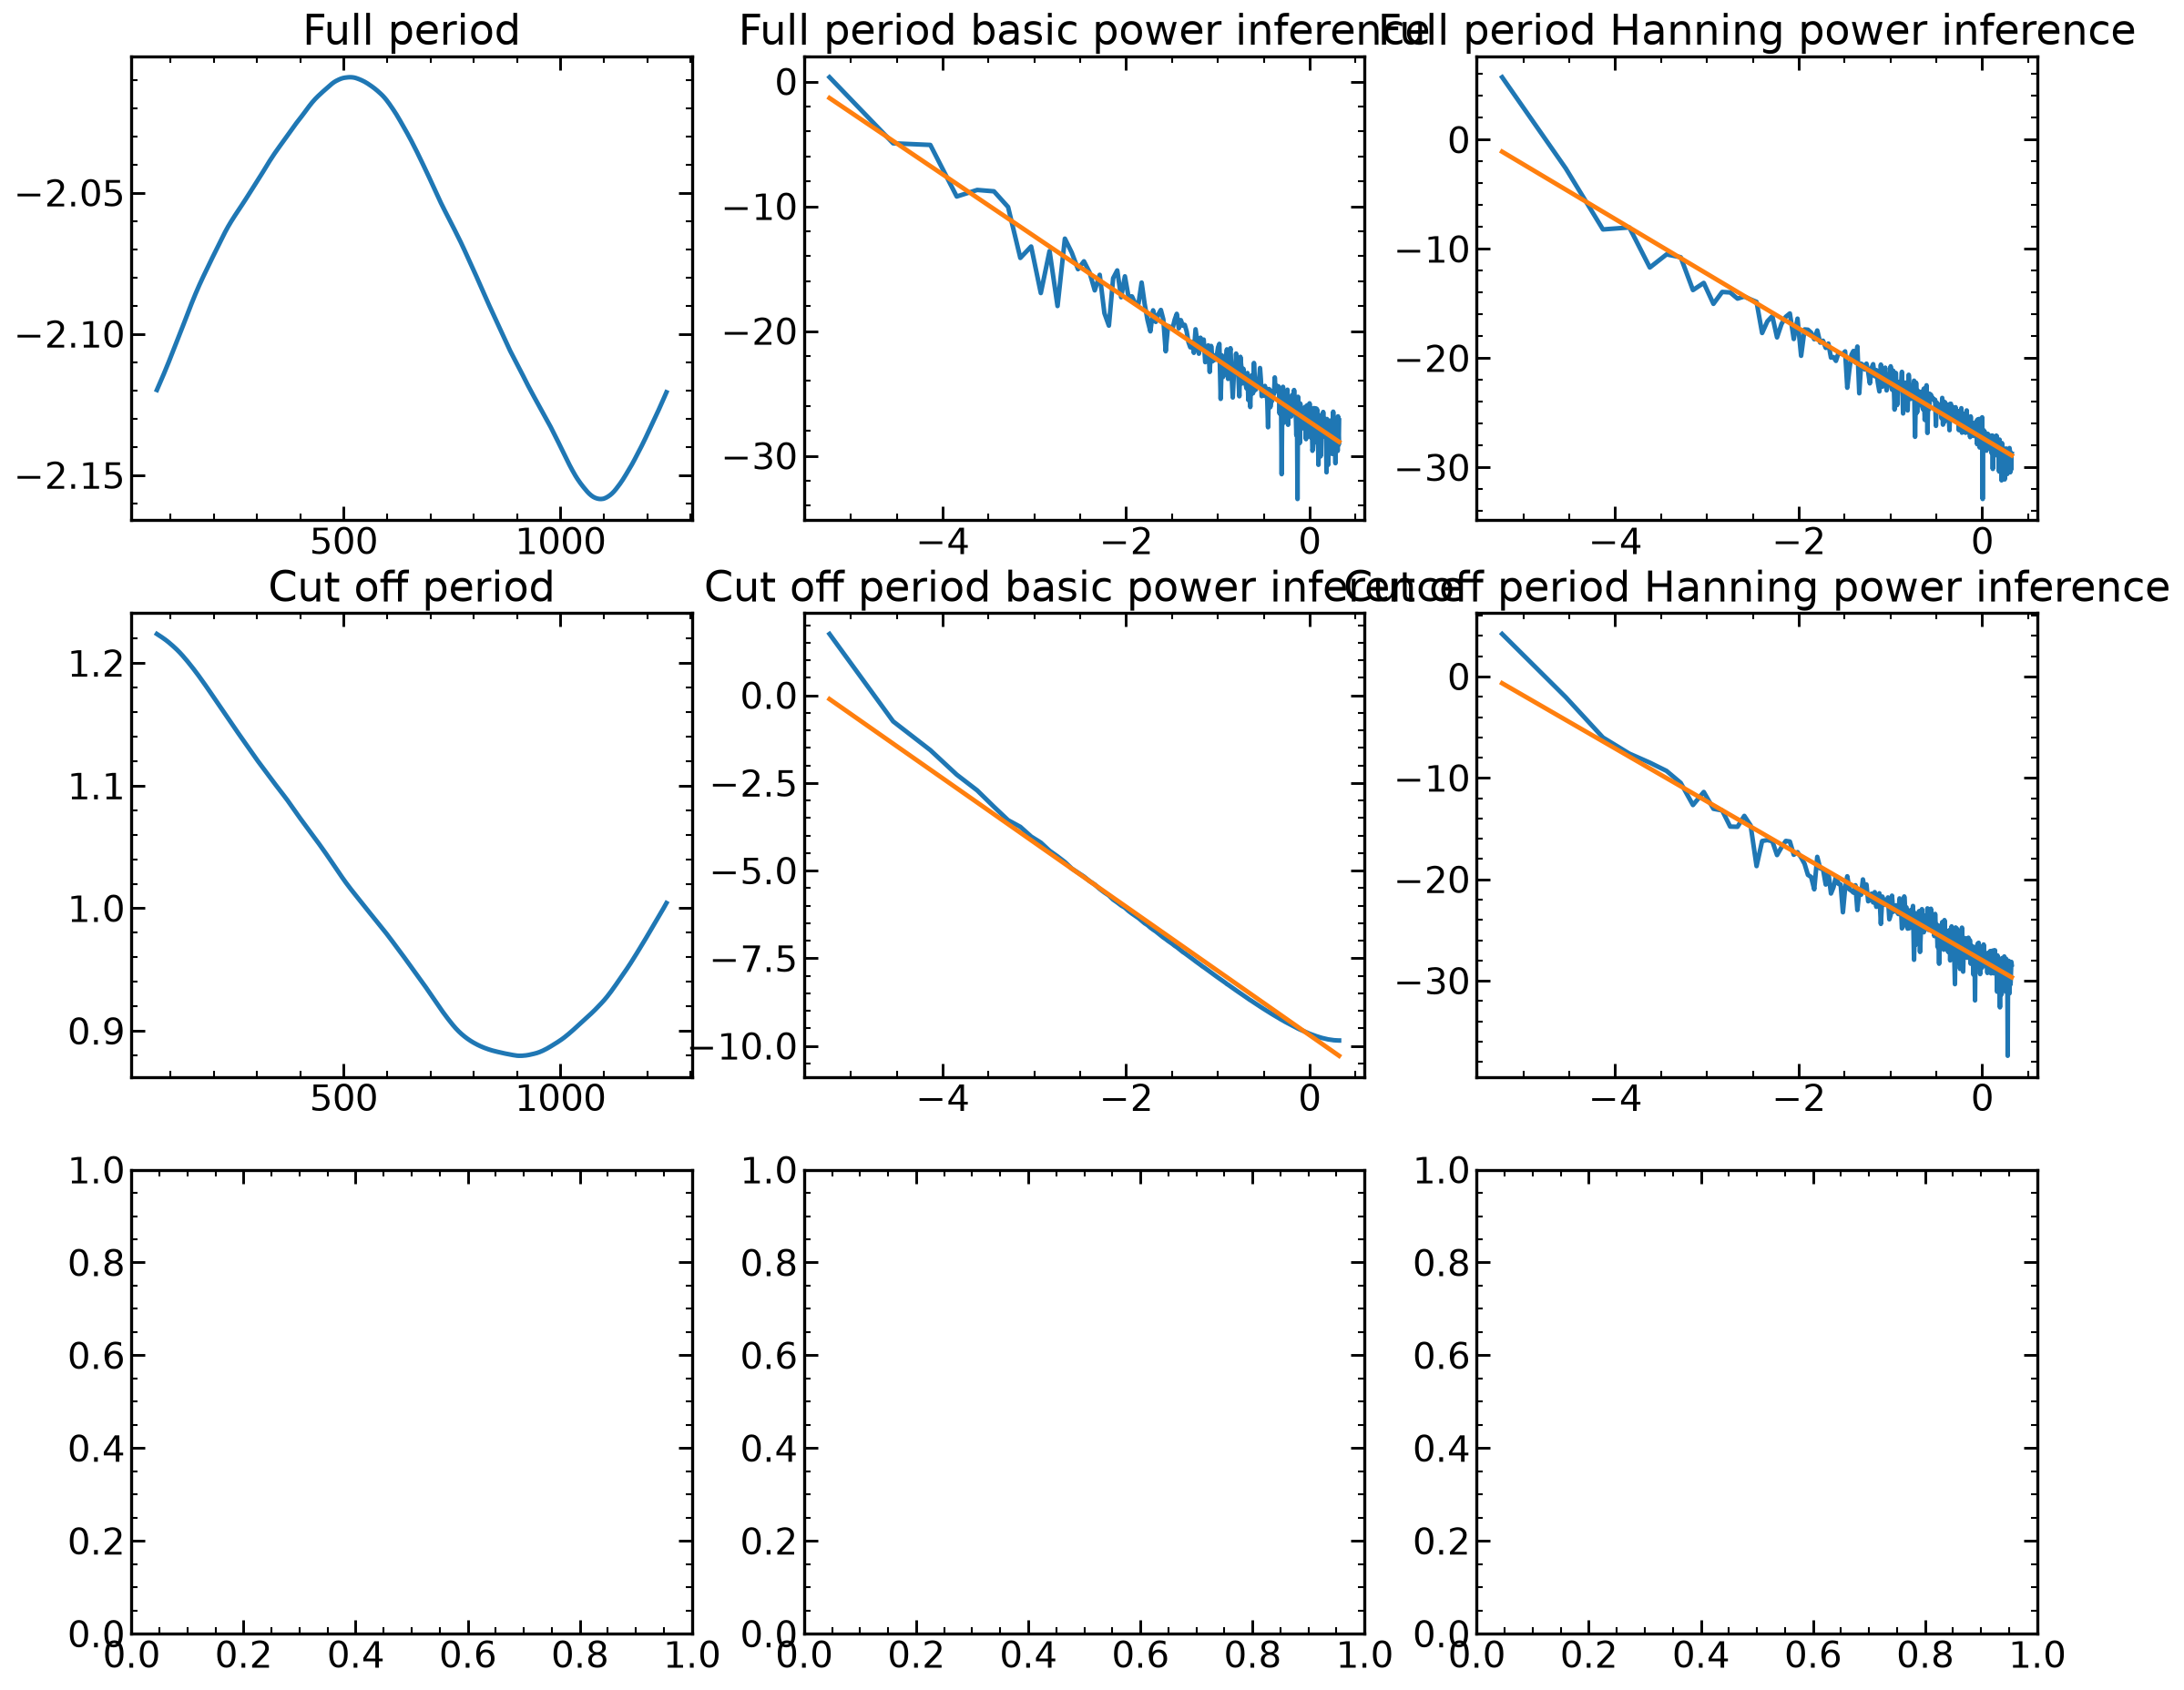

In [10]:
rng = jr.PRNGKey(1)
rng, k1, k2, k3, k4, k5 = jr.split(rng, 6)
noise_1 = jr.normal(k4, shape = (num_dims,))
noise_2 = jr.normal(k2, shape = (10*num_dims,))
test_field = fft_field_hartley(noise_1, length, num_dims, num_dims, (jnp.log(1), jnp.log(2*length), jnp.log(2)))
cut_off_field = fft_field_hartley(noise_2, 10*length, 10*num_dims, num_dims, (jnp.log(1), jnp.log(2*length), jnp.log(2)))

fig, axes = plt.subplots(3, 3, figsize = (18, 15))
log_omegas, log_spectrum, slope_full, intercept = get_spectrum2(test_field, length, num_dims)
axes[0][1].plot(log_omegas, log_spectrum)
axes[0][1].plot(log_omegas, intercept + slope_full*log_omegas)

log_omegas, log_spectrum, slope_cut, intercept = get_spectrum2(cut_off_field, length, num_dims)
axes[1][1].plot(log_omegas, log_spectrum)
axes[1][1].plot(log_omegas, intercept + slope_cut*log_omegas)


axes[0][0].plot(linspace, test_field)
axes[1][0].plot(linspace, cut_off_field)

w = jnp.hanning(num_dims)

log_omegas, log_spectrum, slope_full_hanning, intercept = get_spectrum2(test_field*w, length, num_dims)
axes[0][2].plot(log_omegas, log_spectrum)
axes[0][2].plot(log_omegas, intercept + slope_full_hanning*log_omegas)

log_omegas, log_spectrum, slope_cut_hanning, intercept = get_spectrum2(cut_off_field*w, length, num_dims)
axes[1][2].plot(log_omegas, log_spectrum)
axes[1][2].plot(log_omegas, intercept + slope_cut_hanning*log_omegas)

axes[0][0].set_title("Full period")
axes[0][1].set_title("Full period basic power inference")
axes[0][2].set_title("Full period Hanning power inference")
axes[1][0].set_title("Cut off period")
axes[1][1].set_title("Cut off period basic power inference")
axes[1][2].set_title("Cut off period Hanning power inference")
print(f"Full period slope: {slope_full} Cutoff period slope: {slope_cut} Hanning full period slope: {slope_full_hanning} Hanning cutoff period slope: {slope_cut_hanning}")
